# Credit Risk Default Prediction

## Objective

The objective of this project is to predict whether a customer is likely to default on a loan using historical credit information and machine learning techniques.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

## Exploratory Data Analysis

Understanding the structure of the dataset, missing values, and target distribution.

In [4]:
df = pd.read_csv("cs-training.csv")

df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
print(df.shape)

df.info()

(150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  

In [6]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

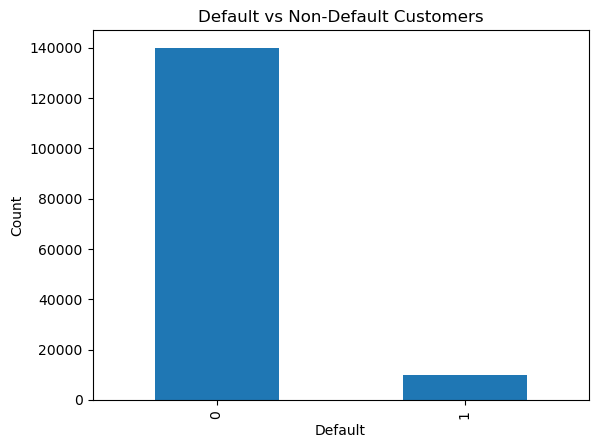

In [8]:
df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar'
)

plt.title("Default vs Non-Default Customers")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

## Data Cleaning

The dataset contains missing values and an unnecessary index column.
Missing values are handled using median imputation and irrelevant columns are removed.

In [11]:
df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [12]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(
    df['MonthlyIncome'].median()
)

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(
    df['NumberOfDependents'].median()
)

In [13]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

## Feature Engineering

New features are created to improve model performance and capture financial behavior patterns.

In [14]:
df['TotalPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse']
    + df['NumberOfTime60-89DaysPastDueNotWorse']
    + df['NumberOfTimes90DaysLate']
)

In [15]:
df['IncomePerDependent'] = (
    df['MonthlyIncome']
    /
    (df['NumberOfDependents'] + 1)
)

In [16]:
df[['TotalPastDue','IncomePerDependent']].head()

,TotalPastDue,IncomePerDependent
0,2,3040.0
1,0,1300.0
2,2,3042.0
3,0,3300.0
4,1,63588.0


## Data Preparation

The dataset is split into training and testing sets for machine learning model development and evaluation.

In [17]:
X = df.drop('SeriousDlqin2yrs', axis=1)

y = df['SeriousDlqin2yrs']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(120000, 12)
(30000, 12)


In [20]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
TotalPastDue                            0
IncomePerDependent                      0
dtype: int64

In [21]:
print(X_train.shape)
print(X_test.shape)

(120000, 12)
(30000, 12)


## Logistic Regression Model

A Logistic Regression model is trained as a baseline classifier for predicting loan default risk.

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))
print("F1 Score:", f1_score(y_test, lr_predictions))
print("ROC-AUC:", roc_auc_score(y_test, lr_predictions))

Accuracy: 0.9347333333333333
Precision: 0.4939759036144578
Recall: 0.041922290388548056
F1 Score: 0.07728557964184732
ROC-AUC: 0.5194634986388611


## Random Forest Model

A Random Forest Classifier is trained to improve predictive performance by combining multiple decision trees.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1 Score:", f1_score(y_test, rf_predictions))
print("ROC-AUC:", roc_auc_score(y_test, rf_predictions))

Accuracy: 0.937
Precision: 0.5565068493150684
Recall: 0.1661554192229039
F1 Score: 0.2559055118110236
ROC-AUC: 0.5784599660655954


## Confusion Matrix

The confusion matrix helps visualize correct and incorrect predictions made by the model.

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)

print(cm)

[[27785   259]
 [ 1631   325]]


## Feature Importance Analysis

Feature importance is used to identify which financial indicators contribute most to loan default prediction.

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                                 Feature  Importance
0   RevolvingUtilizationOfUnsecuredLines    0.225656
10                          TotalPastDue    0.123107
3                              DebtRatio    0.119703
1                                    age    0.102208
11                    IncomePerDependent    0.090701
4                          MonthlyIncome    0.088765
5        NumberOfOpenCreditLinesAndLoans    0.071583
6                NumberOfTimes90DaysLate    0.051085
2   NumberOfTime30-59DaysPastDueNotWorse    0.049568
7           NumberRealEstateLoansOrLines    0.029800


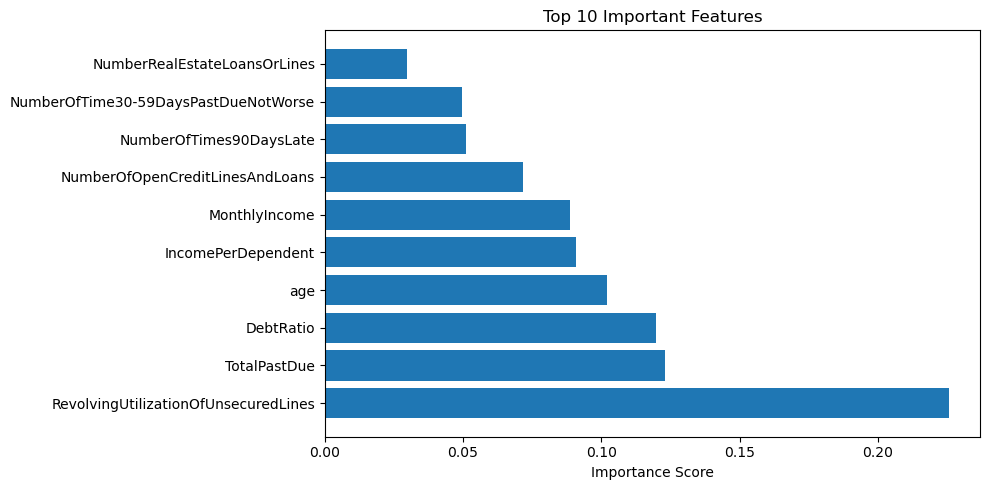

In [41]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

# Conclusion

A Credit Risk Default Prediction system was successfully developed using machine learning techniques.

The project included:

- Data Cleaning
- Missing Value Handling
- Feature Engineering
- Logistic Regression
- Random Forest Classification
- Model Evaluation
- Feature Importance Analysis

The Random Forest model demonstrated strong predictive capability for identifying high-risk customers and can assist financial institutions in making informed lending decisions.